# 04 - Feature Engineering
This notebook assesses the usefulness of different features, indentifying multi-collinearity, correlation with the target variable and any confounding variables

### Imports & Data Load

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
COLORS = ['red', 'blue', 'green', 'cyan', 'magenta', 'yellow', 'black']

In [2]:
cleaned = pd.read_csv('../Data/cleaned.csv')
print(cleaned.columns)
cleaned.head()

Index(['Student ID', 'Age', 'Grade', 'Enjoyment_Score', 'Student_Feeling',
       'Low_Birth_Weight', 'Born_Prematurely', 'Birth_Complications',
       'Family_Math_Difficulty', 'Parent_Perception_Math',
       'Teacher_Perception_Math', 'At Risk', 'Score_Counting', 'Time_Counting',
       'Score_Subitising', 'Time_Subitising', 'Score_Magnitude',
       'Time_Magnitude', 'Score_Place Value', 'Time_Place Value',
       'Score_Number Line', 'Time_Number Line', 'Score_Arithmetic',
       'Time_Arithmetic', 'Score_Fractions', 'Time_Fractions', 'Score_Money',
       'Time_Money', 'Score_Time', 'Time_Time', 'Performance Gap'],
      dtype='str')


,Student ID,Age,Grade,Enjoyment_Score,Student_Feeling,Low_Birth_Weight,Born_Prematurely,Birth_Complications,Family_Math_Difficulty,Parent_Perception_Math,...,Time_Number Line,Score_Arithmetic,Time_Arithmetic,Score_Fractions,Time_Fractions,Score_Money,Time_Money,Score_Time,Time_Time,Performance Gap
0,_ anaya-3,8.9,3,1,1,2,2,2,2,2,...,3.0,0.5,2.0,0.666667,2.7,0.333333,2.3,1.0,3.0,0
1,_abdullah hassan-2,8.4,2,1,1,2,2,2,2,2,...,3.0,1.0,2.5,0.666667,2.0,1.000000,2.7,1.0,2.5,0
2,1-3,8.9,3,1,1,2,2,2,2,2,...,3.5,1.0,3.0,0.333333,3.0,0.666667,3.7,1.0,3.0,0
3,1016,8.0,2,2,2,0,0,0,0,0,...,4.5,1.0,3.0,0.333333,3.7,0.666667,3.0,1.0,3.0,0
4,1017,8.0,2,1,1,2,2,2,2,2,...,3.5,0.5,3.5,0.666667,4.7,0.666667,3.0,1.0,4.0,-1


### Multicolinearity Check using Variance Inflation Factor (VIF)

                    Feature        VIF
6       Birth_Complications  41.194883
4          Low_Birth_Weight  27.614577
5          Born_Prematurely  25.498825
7    Family_Math_Difficulty  11.983542
8    Parent_Perception_Math   9.935379
15           Time_Magnitude   2.947236
17         Time_Place Value   2.719496
11            Time_Counting   2.201906
13          Time_Subitising   2.140766
18        Score_Number Line   1.934998
1                     Grade   1.917658
21          Time_Arithmetic   1.877397
25               Time_Money   1.804335
19         Time_Number Line   1.790146
0                       Age   1.683844
24              Score_Money   1.672202
23           Time_Fractions   1.666051
16        Score_Place Value   1.659161
27                Time_Time   1.577041
14          Score_Magnitude   1.504497
26               Score_Time   1.491956
3           Student_Feeling   1.320412
2           Enjoyment_Score   1.309264
9   Teacher_Perception_Math   1.262463
10           Score_Counti

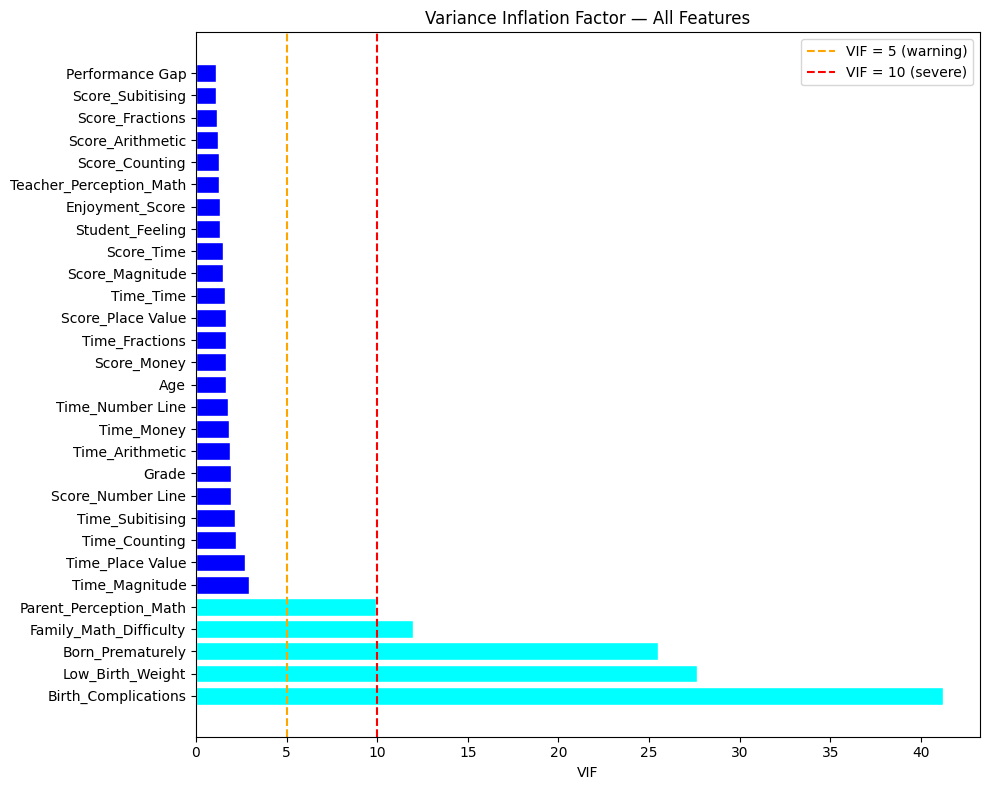

In [3]:
df = cleaned.drop(columns=['At Risk', 'Student ID'])

X_vif_const = add_constant(df)

vif_data = pd.DataFrame({
    'Feature': df.columns,
    'VIF': [variance_inflation_factor(X_vif_const.values, i+1) 
            for i in range(len(df.columns))]
}).sort_values('VIF', ascending=False)

print(vif_data)

# visualise
plt.figure(figsize=(10, 8))
plt.barh(vif_data['Feature'], vif_data['VIF'], 
         color=[COLORS[3] if v > 5 else COLORS[1] for v in vif_data['VIF']],
         edgecolor='white')
plt.axvline(5, color='orange', linestyle='--', label='VIF = 5 (warning)')
plt.axvline(10, color='red', linestyle='--', label='VIF = 10 (severe)')
plt.title('Variance Inflation Factor — All Features')
plt.xlabel('VIF')
plt.legend()
plt.tight_layout()
plt.show()

### Correlation Matrix among Features

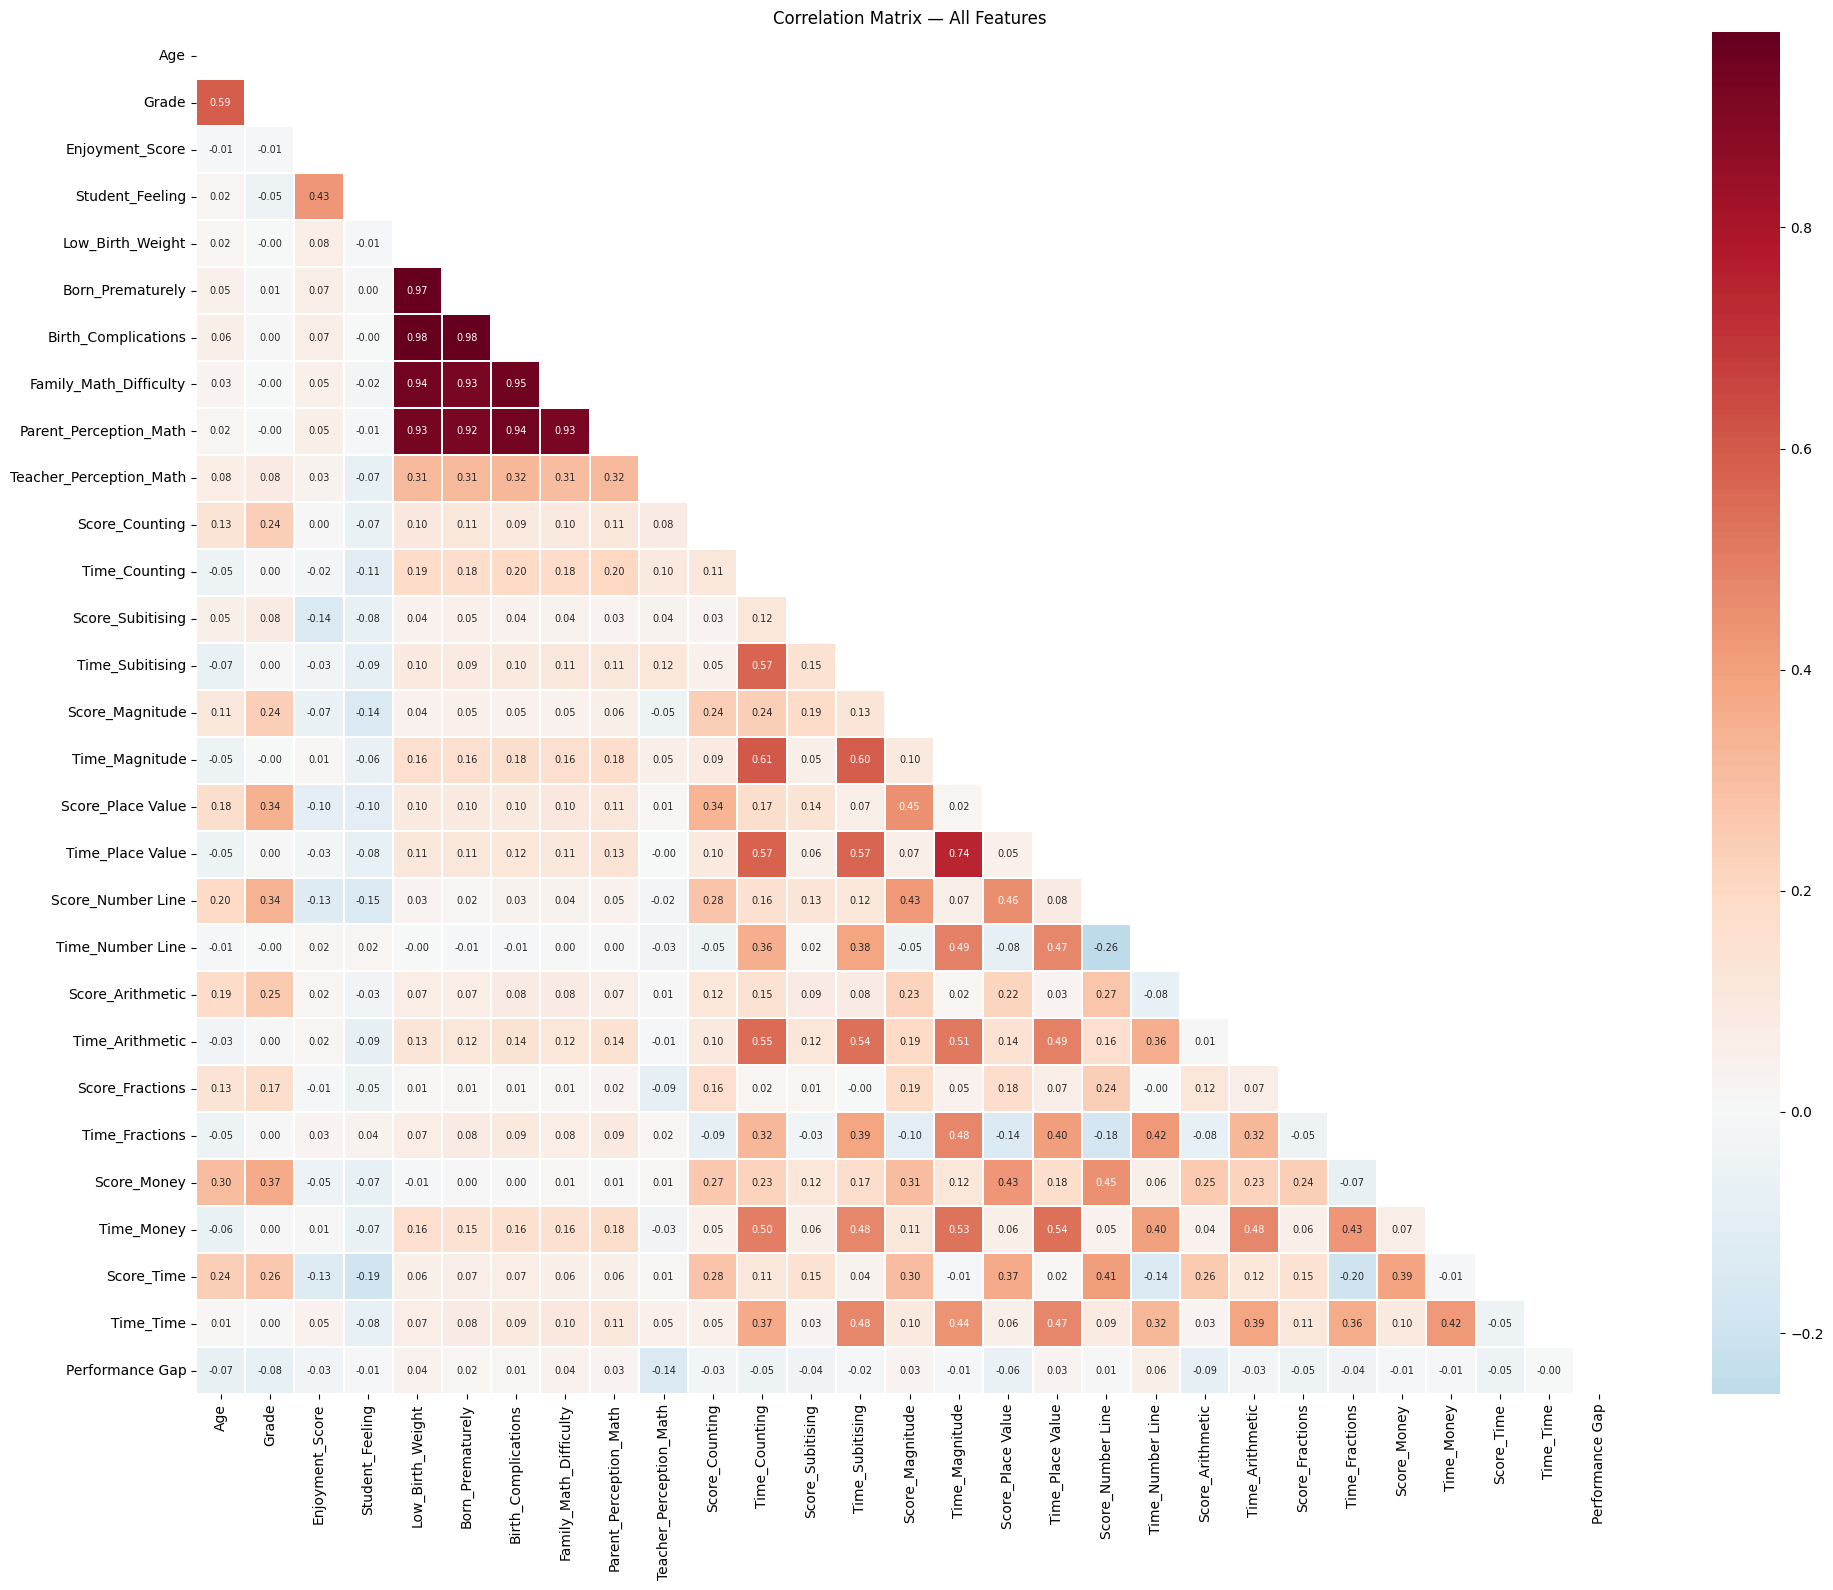

In [4]:
plt.figure(figsize=(20, 16))
corr_matrix = df.corr()

# mask upper triangle for cleaner view
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            mask=mask,
            cmap='RdBu_r',
            center=0,
            annot=True,
            fmt='.2f',
            annot_kws={'size': 7},
            linewidths=0.3)
plt.title('Correlation Matrix — All Features')
plt.tight_layout()
plt.show()

### Correlation with the Target Variable

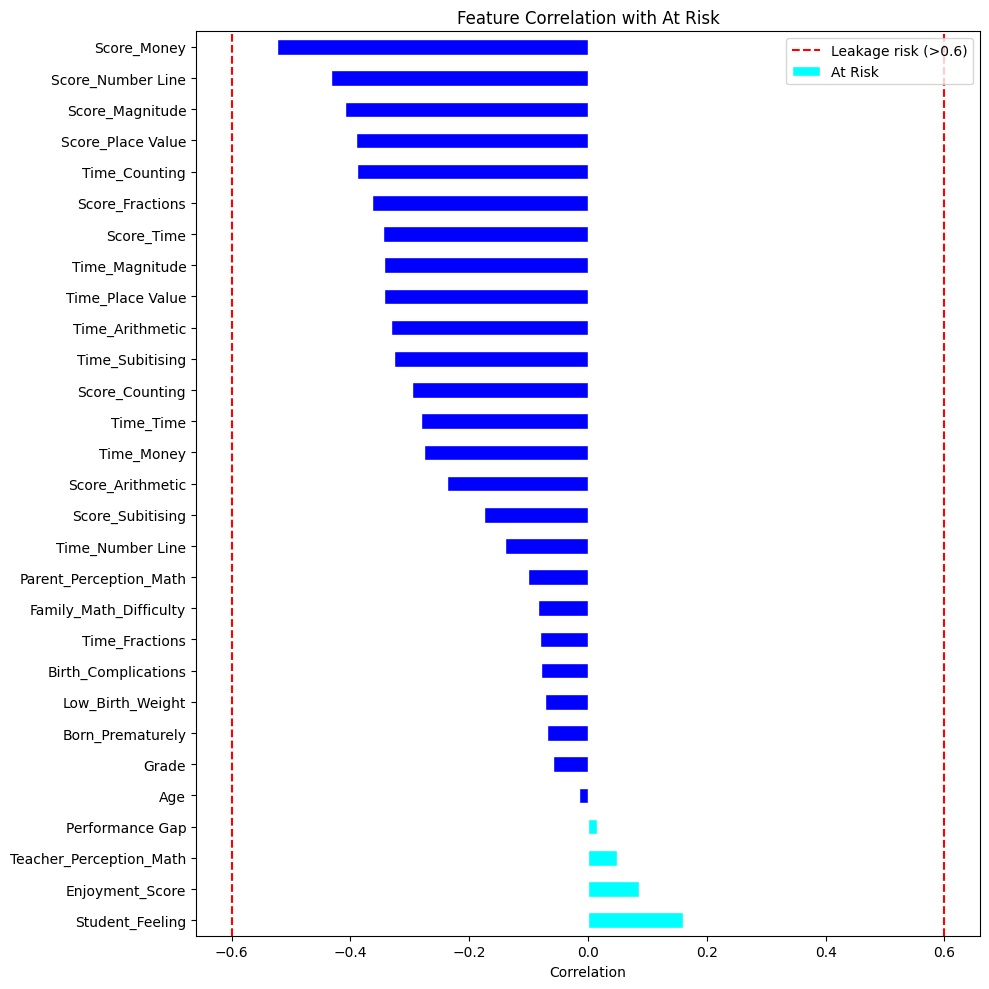

High correlations with At Risk (>0.4):
Score_Magnitude     -0.409605
Score_Number Line   -0.433315
Score_Money         -0.522875
Name: At Risk, dtype: float64


In [5]:
df_corr = df.copy()
df_corr['At Risk'] = cleaned['At Risk'].values

target_corr = df_corr.corr()['At Risk'].drop('At Risk')
target_corr = target_corr.sort_values(ascending=False)

plt.figure(figsize=(10, 10))
target_corr.plot(kind='barh',
    color=[COLORS[3] if v > 0 else COLORS[1] for v in target_corr],
    edgecolor='white')
plt.axvline(0.6, color='red', linestyle='--', label='Leakage risk (>0.6)')
plt.axvline(-0.6, color='red', linestyle='--')
plt.title('Feature Correlation with At Risk')
plt.xlabel('Correlation')
plt.legend()
plt.tight_layout()
plt.show()

# print high correlations specifically
print('High correlations with At Risk (>0.4):')
print(target_corr[abs(target_corr) > 0.4])

### Drop Uncontributing Columns

In [6]:
family_hist_columns = [ 'Birth_Complications', 'Low_Birth_Weight', 'Born_Prematurely', 'Family_Math_Difficulty', 'Parent_Perception_Math' ]
engineered = cleaned.drop(columns = family_hist_columns)
engineered.columns

Index(['Student ID', 'Age', 'Grade', 'Enjoyment_Score', 'Student_Feeling',
       'Teacher_Perception_Math', 'At Risk', 'Score_Counting', 'Time_Counting',
       'Score_Subitising', 'Time_Subitising', 'Score_Magnitude',
       'Time_Magnitude', 'Score_Place Value', 'Time_Place Value',
       'Score_Number Line', 'Time_Number Line', 'Score_Arithmetic',
       'Time_Arithmetic', 'Score_Fractions', 'Time_Fractions', 'Score_Money',
       'Time_Money', 'Score_Time', 'Time_Time', 'Performance Gap'],
      dtype='str')

In [7]:
engineered.to_csv('../Data/engineered.csv', index=False)